In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from pathlib import Path

def season_code(start_year):
    return f"{start_year % 100:02d}{(start_year + 1) % 100:02d}"   # 2023 → "2324"

def load_pl(first=2010, last=2024, cache="data/pl_matches.csv"):
    path = Path(cache)
    if path.exists():
        return pd.read_csv(path, parse_dates=["Date"], low_memory=False)
    frames = []
    for y in range(first, last + 1):
        url = f"https://www.football-data.co.uk/mmz4281/{season_code(y)}/E0.csv"
        s = pd.read_csv(url, encoding="latin-1")      # older files aren't always UTF-8
        s = s.dropna(subset=["HomeTeam"])             # some files have blank trailing rows
        s["Season"] = f"{y}-{str(y + 1)[-2:]}"         # "2023-24"
        frames.append(s)
    out = pd.concat(frames, ignore_index=True)
    out["Date"] = pd.to_datetime(out["Date"], dayfirst=True, format="mixed")   # old seasons use dd/mm/yy
    path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(path, index=False)
    return out

In [12]:
pl = load_pl(2012, 2024)

In [13]:
pl["TotalGoals"] = pl.FTHG + pl.FTAG

In [14]:
sns.set_theme(style="whitegrid")

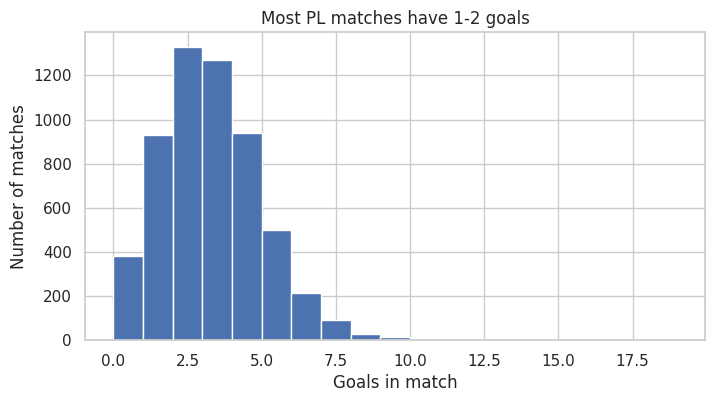

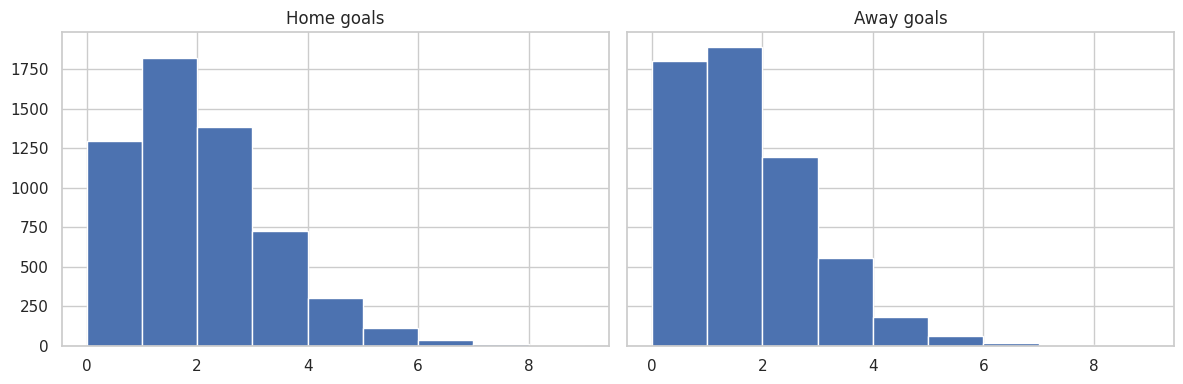

In [19]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(pl.TotalGoals, bins=range(0, 20), edgecolor="white")
ax.set_xlabel("Goals in match")
ax.set_ylabel("Number of matches")
ax.set_title("Most PL matches have 1-2 goals")
plt.show()

fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
axes[0].hist(pl.FTHG, bins=range(0,10)); axes[0].set_title("Home goals")
axes[1].hist(pl.FTAG, bins=range(0,10)); axes[1].set_title("Away goals")
plt.tight_layout()

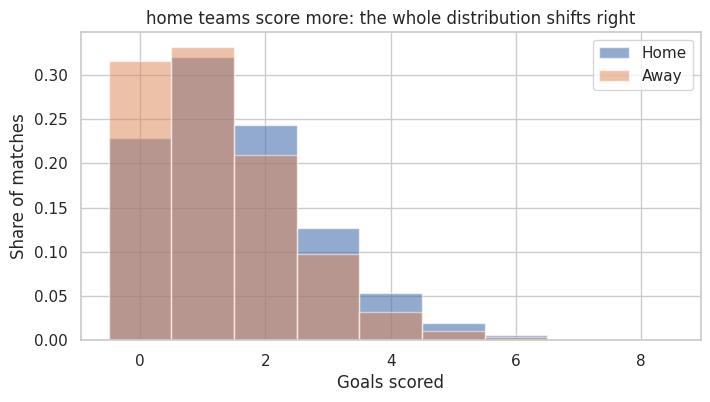

In [25]:
fig, ax = plt.subplots(figsize=(8,4))
bins = np.arange(-0.5, 9.5,1)
ax.hist(pl.FTHG, bins=bins, alpha=0.6, label="Home", density=True)
ax.hist(pl.FTAG, bins=bins, alpha=0.5, label="Away", density=True)
ax.set_xlabel("Goals scored"); ax.set_ylabel("Share of matches")
ax.set_title("home teams score more: the whole distribution shifts right")
ax.legend()

Text(0.5, 1.0, 'Goals per match by season')

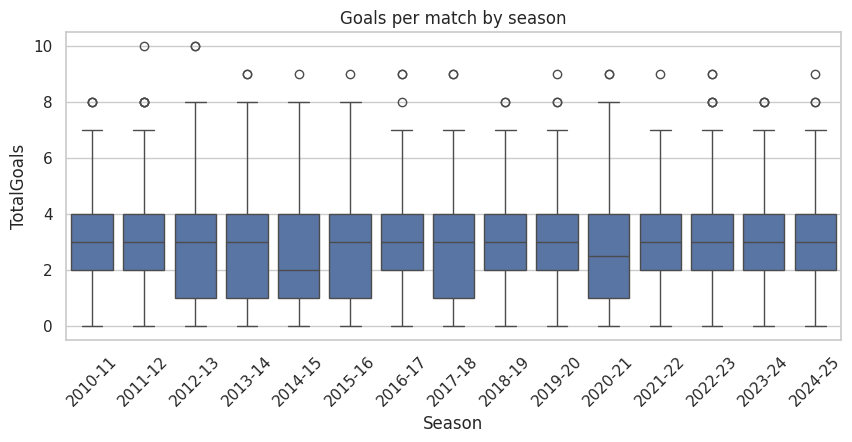

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=pl, x="Season", y="TotalGoals", ax=ax)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Goals per match by season")

Text(0.5, 1.0, 'More shots on target → more goals (but lots of noise)')

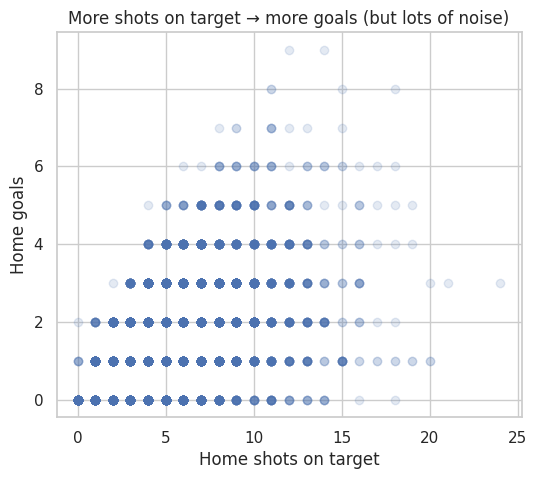

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pl.HST, pl.FTHG, alpha=0.15)
ax.set_xlabel("Home shots on target"); ax.set_ylabel("Home goals")
ax.set_title("More shots on target → more goals (but lots of noise)")

In [28]:
avg = pl.groupby("HST")["FTHG"].agg(["mean", "size"])
avg

,mean,size
HST,,
0.0,0.078652,89
1.0,0.392857,308
2.0,0.665455,550
3.0,1.005420,738
4.0,1.279245,795
5.0,1.545689,777
6.0,1.873323,671
7.0,2.114120,517
8.0,2.116580,386


In [31]:
avg = avg[avg["size"] >= 20] #ignoring rare values

Text(0.5, 1.0, 'Each extra shot on target ≈ +0.3 goals')

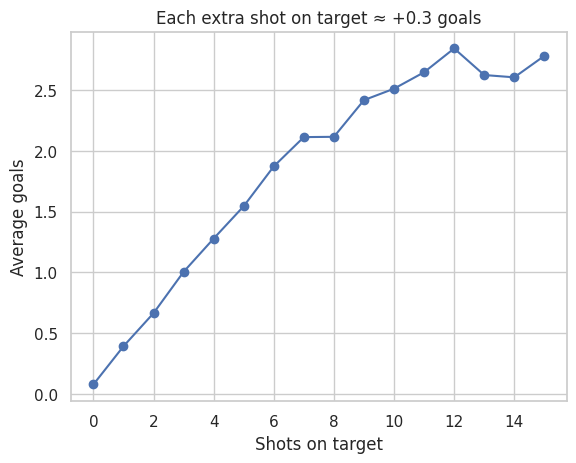

In [32]:
fig, ax = plt.subplots()
ax.plot(avg.index, avg["mean"], marker="o")
ax.set_xlabel("Shots on target"); ax.set_ylabel("Average goals")
ax.set_title("Each extra shot on target ≈ +0.3 goals")

Text(0.5, 1.0, '2023–24: who was strongest at home?')

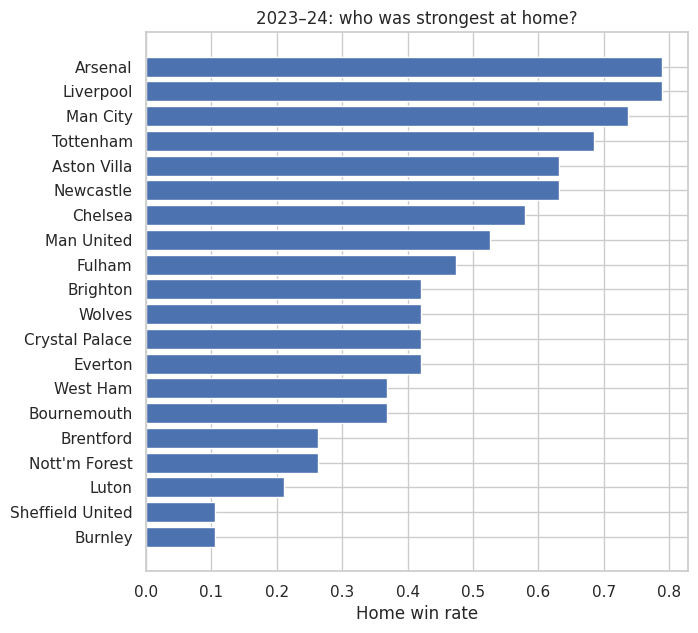

In [33]:
s =pl[pl.Season == "2023-24"]
home_win = s.groupby("HomeTeam")["FTR"].apply(lambda r: (r == "H").mean()).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(home_win.index, home_win.values)
ax.set_xlabel("Home win rate"); ax.set_title("2023–24: who was strongest at home?")

Text(0.5, 1.0, 'Home advantage collapsed in 2020–21 (empty stadiums)')

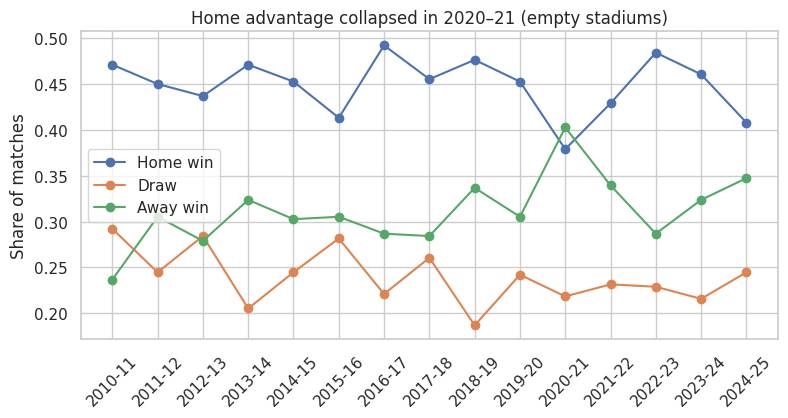

In [34]:
rates = pl.groupby("Season")["FTR"].value_counts(normalize=True).unstack()
fig, ax = plt.subplots(figsize=(9, 4))
for col, lab in [("H", "Home win"), ("D", "Draw"), ("A", "Away win")]:
    ax.plot(rates.index, rates[col], marker="o", label=lab)
ax.tick_params(axis="x", rotation=45); ax.legend()
ax.set_ylabel("Share of matches")
ax.set_title("Home advantage collapsed in 2020–21 (empty stadiums)")

<Axes: >

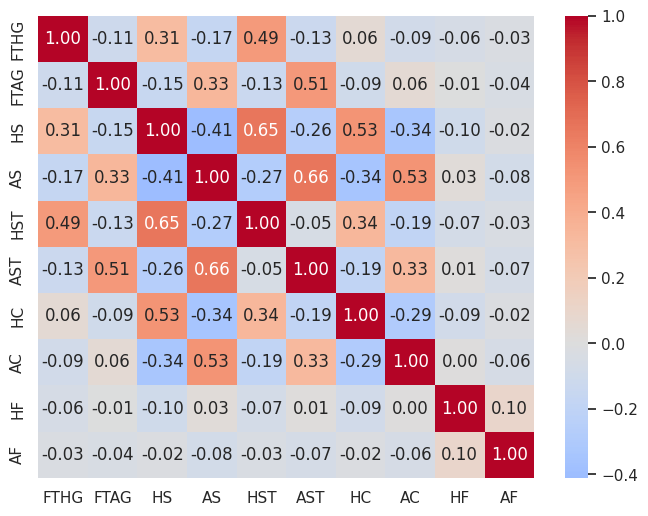

In [35]:
cols = ["FTHG", "FTAG", "HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pl[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)

<Axes: xlabel='TotalGoals', ylabel='Count'>

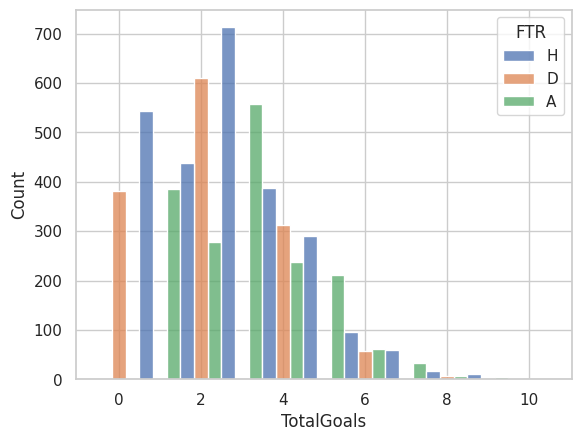

In [36]:
sns.histplot(data=pl, x="TotalGoals", hue="FTR", discrete=True, multiple="dodge")


<Axes: xlabel='HST', ylabel='FTHG'>

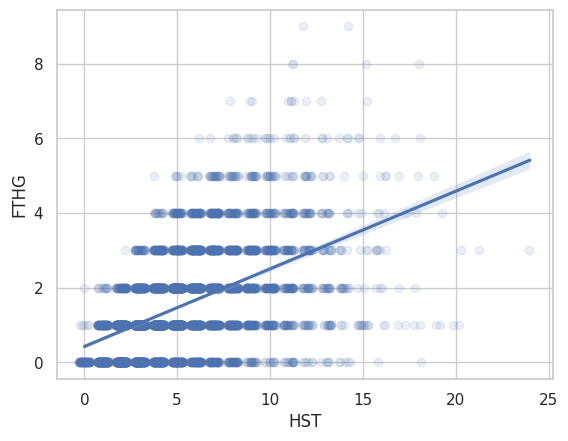

In [37]:
sns.regplot(data=pl, x="HST", y="FTHG", x_jitter=0.3, scatter_kws={"alpha": 0.1})


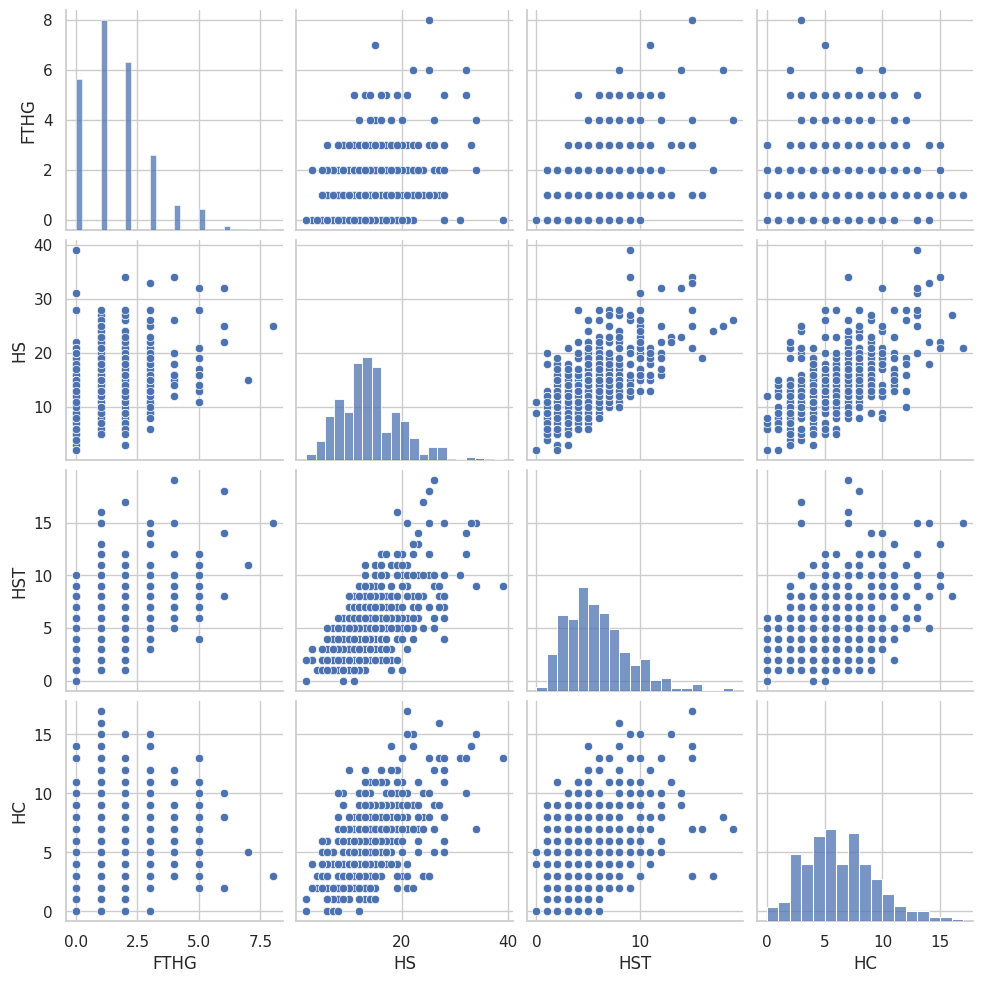

In [38]:
sns.pairplot(pl[["FTHG", "HS", "HST", "HC"]].sample(500, random_state=0))


Home vs away, side by side

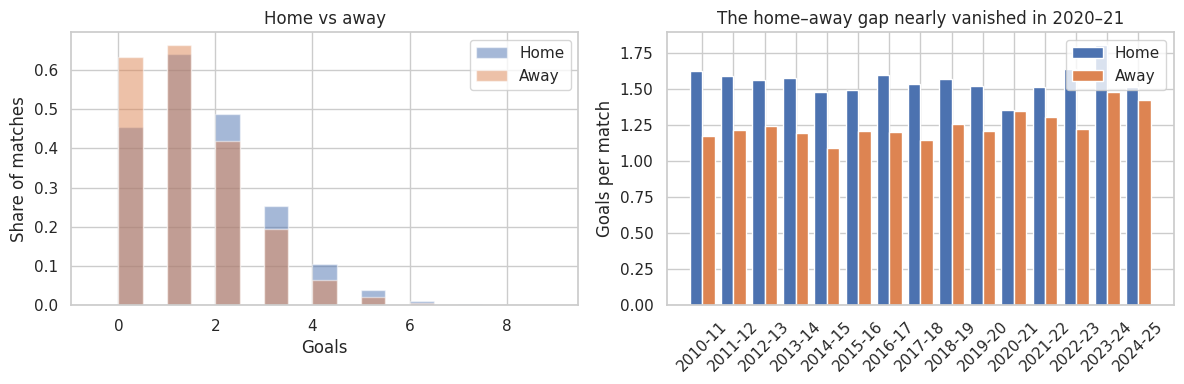

In [55]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
bin = np.arange(-0.5,9.5,0.5)
ax[0].hist(pl.FTHG, bins=bin, alpha=0.5, density=True, label="Home")
ax[0].hist(pl.FTAG, bins=bin, alpha=0.5, density=True, label="Away")
ax[0].set_xlabel("Goals")
ax[0].set_ylabel("Share of matches")
ax[0].set_title("Home vs away")
ax[0].legend()

g = pl.groupby("Season")[["FTHG","FTAG"]].mean()
x = np.arange(len(g))

ax[1].bar(x - 0.2, g.FTHG, width=0.4, label="Home")
ax[1].bar(x + 0.2, g.FTAG, width=0.4, label="Away")
ax[1].set_xticks(x, g.index, rotation=45)
ax[1].set(ylabel="Goals per match", title="The home–away gap nearly vanished in 2020–21")
ax[1].legend()
plt.tight_layout()

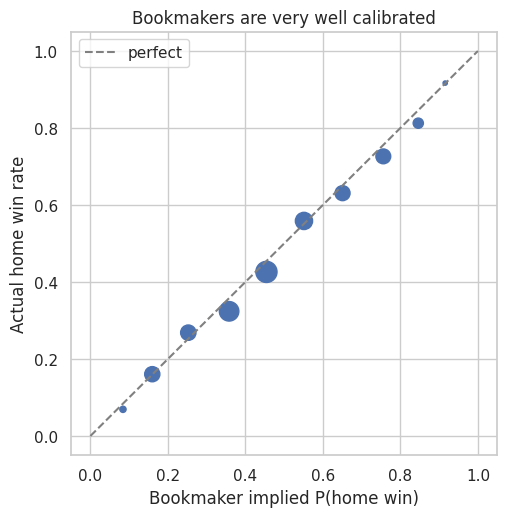

In [63]:
d = pl.dropna(subset=["B365H"]).copy()
d["p_imp"] = 1/d.B365H
d["home_win"] = (d.FTR == "H").astype(int)
d["bin"]=pd.cut(d.p_imp, bins=np.linspace(0,1,11))
cal = d.groupby("bin", observed=True).agg(p_imp=("p_imp", "mean"), actual=("home_win", "mean"), n=("home_win", "size"))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
ax.scatter(cal.p_imp, cal.actual, s=cal.n / 5)
ax.set(xlabel="Bookmaker implied P(home win)", ylabel="Actual home win rate",
       title="Bookmakers are very well calibrated")
ax.legend()

(array([0, 1, 2, 3]),
 [Text(0, 0, '(False, False)'),
  Text(1, 0, '(False, True)'),
  Text(2, 0, '(True, False)'),
  Text(3, 0, '(True, True)')])

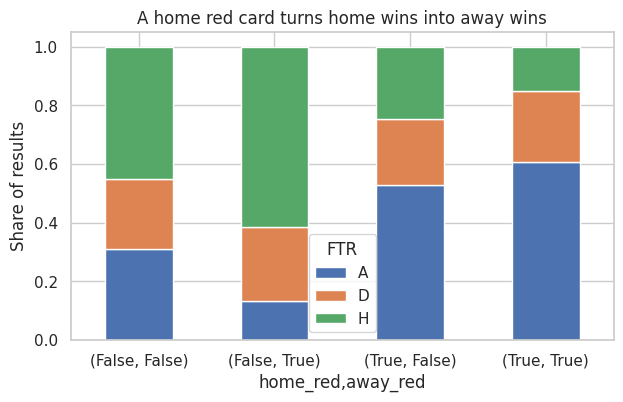

In [64]:
d = pl.copy()
d["home_red"] = d.HR > 0
d["away_red"] = d.AR > 0
grp = d.groupby(["home_red", "away_red"])["FTR"].value_counts(normalize=True).unstack()
grp.plot(kind="bar", stacked=True, figsize=(7, 4), title="A home red card turns home wins into away wins")
plt.ylabel("Share of results"); plt.xticks(rotation=0)